In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from aeon.datasets import load_classification
from aeon.visualisation import create_multi_comparison_matrix, plot_critical_difference

GENERATED_RESULTS = Path("..") / "generated_results"
FIGURES = Path("figures2")
FIGURES.mkdir(exist_ok=True)

112 datasets


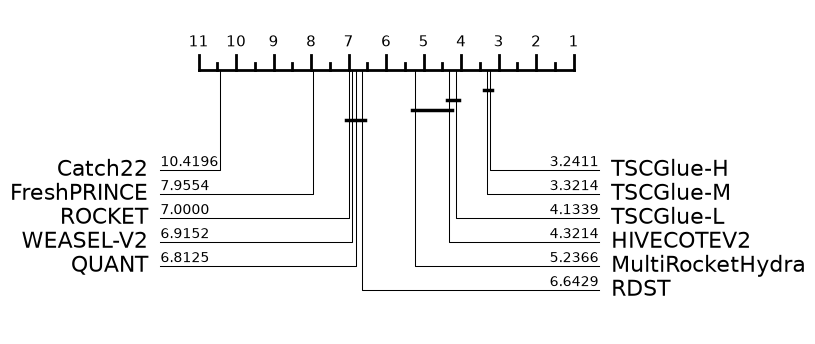

In [2]:
# Accuracy CD diagram: baselines + accuracy-tuned TSCGlue presets, redrawn from the
# per-dataset mean accuracies that 080-benchmark-results.ipynb writes via tsml_eval.
means = pd.read_csv(GENERATED_RESULTS / "tscbench" / "Accuracy" / "accuracy_mean.csv", index_col=0)
means = means[[c for c in means.columns if not c.startswith("TSCGlue-") or c.endswith("-accuracy")]].dropna()
print(f"{means.shape[0]} datasets")

labels = [
    f"TSCGlue-{c.split('-')[1][0].upper()}" if c.startswith("TSCGlue-") else c for c in means.columns
]
labels = [{"WEASEL_V2": "WEASEL-V2"}.get(c, c) for c in labels]
fig, ax = plot_critical_difference(means.values, labels, alpha=0.05)
fig.savefig(FIGURES / "critical_difference_accuracy.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

112 datasets


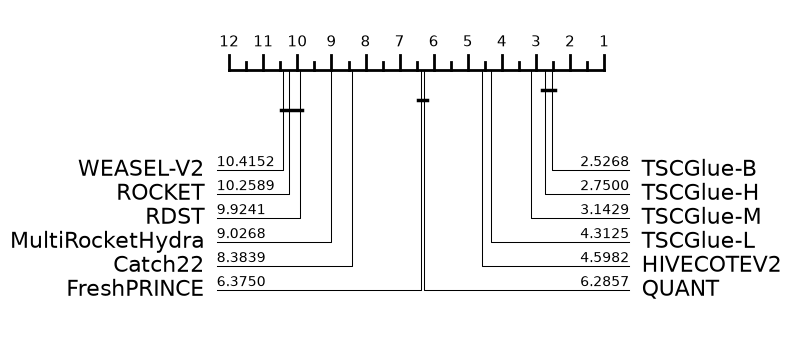

In [3]:
# Log loss CD diagram: baselines + log_loss-tuned TSCGlue presets (B = best preset).
means = pd.read_csv(GENERATED_RESULTS / "tscbench" / "LogLoss" / "logloss_mean.csv", index_col=0)
means = means[[c for c in means.columns if not c.startswith("TSCGlue-") or c.endswith("-log_loss")]].dropna()
print(f"{means.shape[0]} datasets")

labels = [
    f"TSCGlue-{c.split('-')[1][0].upper()}" if c.startswith("TSCGlue-") else c for c in means.columns
]
labels = [{"WEASEL_V2": "WEASEL-V2"}.get(c, c) for c in labels]
fig, ax = plot_critical_difference(means.values, labels, lower_better=True, alpha=0.05)
fig.savefig(FIGURES / "critical_difference_logloss.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

112 datasets


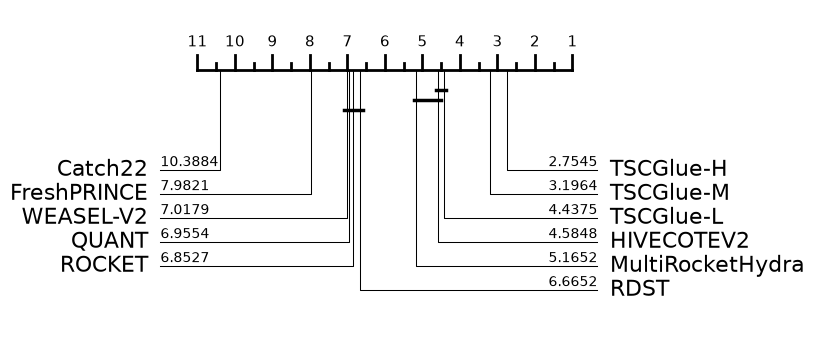

In [4]:
# F1 CD diagram: baselines + accuracy-tuned TSCGlue presets.
means = pd.read_csv(GENERATED_RESULTS / "tscbench" / "F1" / "f1_mean.csv", index_col=0)
means = means[[c for c in means.columns if not c.startswith("TSCGlue-") or c.endswith("-accuracy")]].dropna()
print(f"{means.shape[0]} datasets")

labels = [
    f"TSCGlue-{c.split('-')[1][0].upper()}" if c.startswith("TSCGlue-") else c for c in means.columns
]
labels = [{"WEASEL_V2": "WEASEL-V2"}.get(c, c) for c in labels]
fig, ax = plot_critical_difference(means.values, labels, alpha=0.05)
fig.savefig(FIGURES / "critical_difference_f1.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

112 datasets


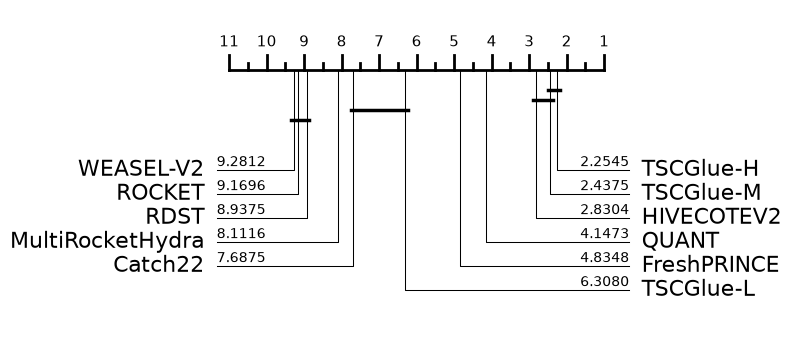

In [5]:
# ROC AUC CD diagram: baselines + accuracy-tuned TSCGlue presets.
means = pd.read_csv(GENERATED_RESULTS / "tscbench" / "AUROC" / "auroc_mean.csv", index_col=0)
means = means[[c for c in means.columns if not c.startswith("TSCGlue-") or c.endswith("-accuracy")]].dropna()
print(f"{means.shape[0]} datasets")

labels = [
    f"TSCGlue-{c.split('-')[1][0].upper()}" if c.startswith("TSCGlue-") else c for c in means.columns
]
labels = [{"WEASEL_V2": "WEASEL-V2"}.get(c, c) for c in labels]
fig, ax = plot_critical_difference(means.values, labels, alpha=0.05)
fig.savefig(FIGURES / "critical_difference_auroc.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

112 datasets


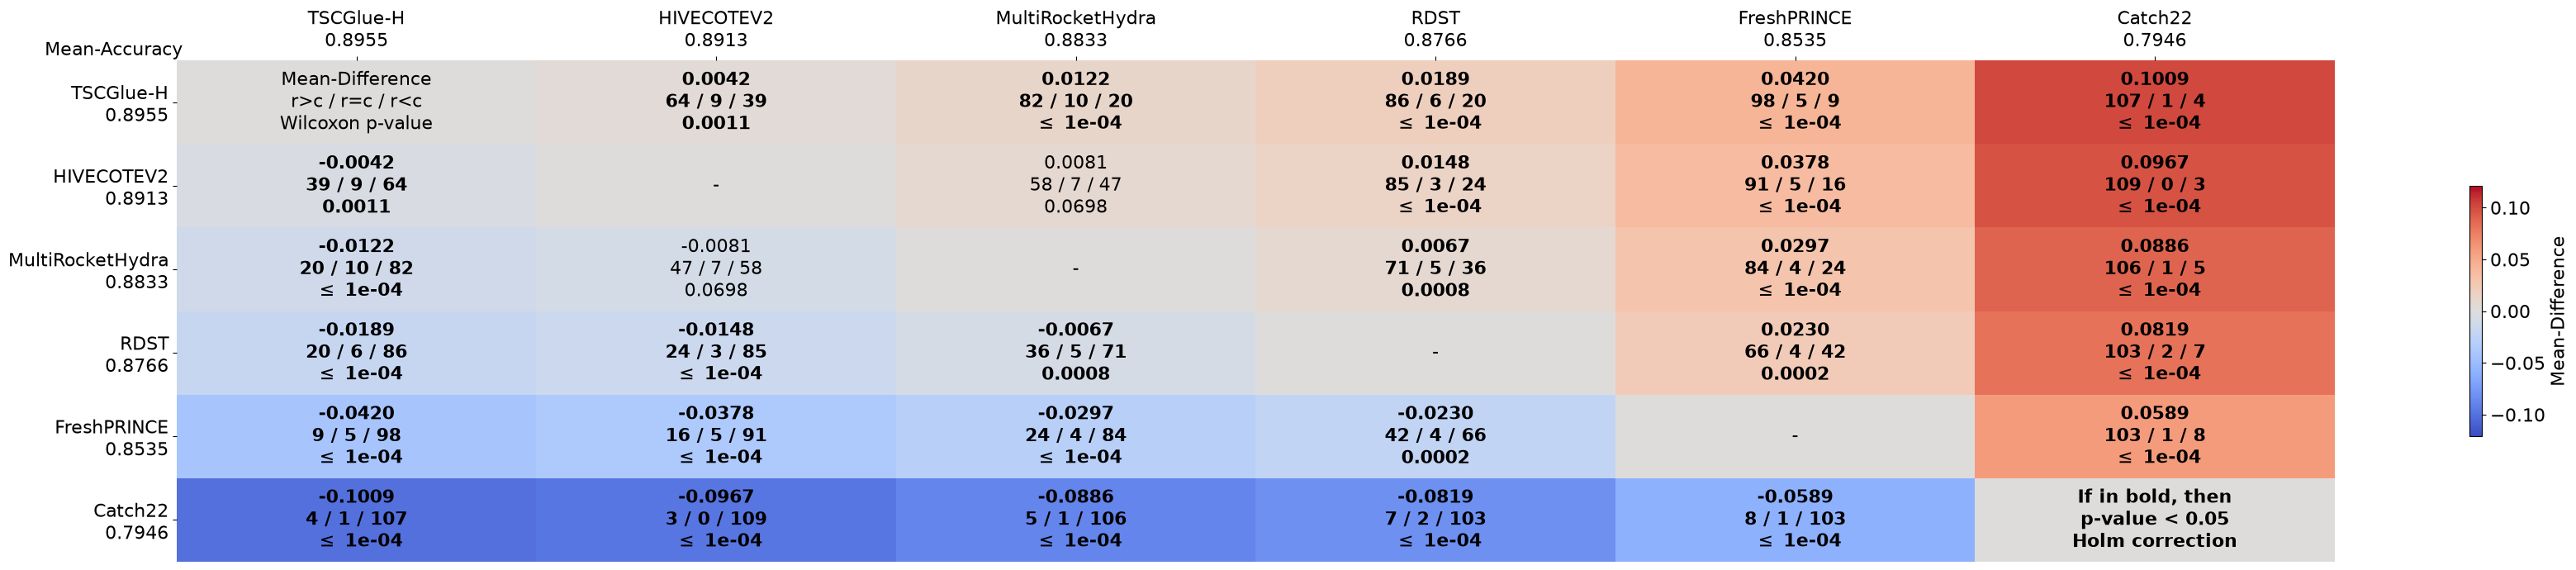

In [6]:
# Accuracy multi-comparison matrix: the accuracy CD diagram's models, TSCGlue-H only, without ROCKET, QUANT and WEASEL-V2.
means = pd.read_csv(GENERATED_RESULTS / "tscbench" / "Accuracy" / "accuracy_mean.csv", index_col=0)
means = means[[c for c in means.columns if not c.startswith("TSCGlue-") or c == "TSCGlue-high-accuracy"]].dropna()
means = means.drop(columns=["ROCKET", "QUANT", "WEASEL_V2"])
print(f"{means.shape[0]} datasets")

labels = [
    f"TSCGlue-{c.split('-')[1][0].upper()}" if c.startswith("TSCGlue-") else c for c in means.columns
]
labels = [{"WEASEL_V2": "WEASEL-V2"}.get(c, c) for c in labels]
fig = create_multi_comparison_matrix(
    means.set_axis(labels, axis=1),
    statistic_name="Accuracy",
    # Two-sided test: aeon's default one-sided test + Holm reports the wrong direction's
    # p-value for pairs where the weaker model comes first in the column order.
    pvalue_test_params={"zero_method": "pratt", "alternative": "two-sided"},
    pvalue_correction="Holm",
    font_size=16,
)
fig.savefig(FIGURES / "multi_comparison_matrix_accuracy.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

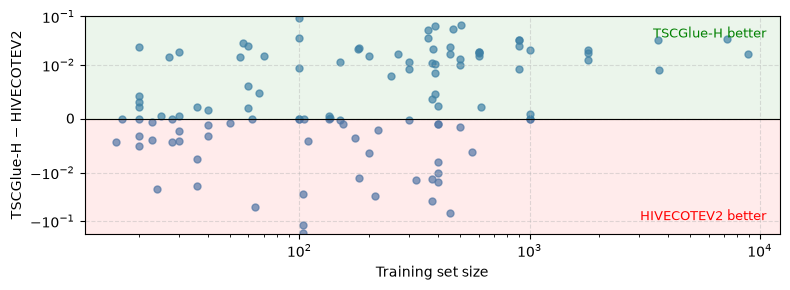

In [7]:
# Per-dataset accuracy difference TSCGlue-H - HIVECOTEV2 against training set size.
means = pd.read_csv(GENERATED_RESULTS / "tscbench" / "Accuracy" / "accuracy_mean.csv", index_col=0)
diff = (means["TSCGlue-high-accuracy"] - means["HIVECOTEV2"]).dropna()
n_train = pd.Series(
    {d: len(load_classification(d, split="train", extract_path="../data")[1]) for d in diff.index}
)

fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(n_train[diff.index], diff, s=25, alpha=0.7, color="steelblue")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Training set size")
ax.set_ylabel("TSCGlue-H − HIVECOTEV2")
ax.set_xscale("log")
ax.grid(True, linestyle="--", alpha=0.4)
ylim = ax.get_ylim()
ax.axhspan(0, ylim[1], alpha=0.08, color="green")
ax.axhspan(ylim[0], 0, alpha=0.08, color="red")
ax.text(0.98, 0.95, "TSCGlue-H better", transform=ax.transAxes, ha="right", va="top", fontsize=9, color="green")
ax.text(0.98, 0.05, "HIVECOTEV2 better", transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="red")
ax.set_ylim(ylim)
ax.set_yscale("symlog", linthresh=0.01)
plt.tight_layout()
fig.savefig(FIGURES / "hc2_vs_tscglue.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

112 datasets


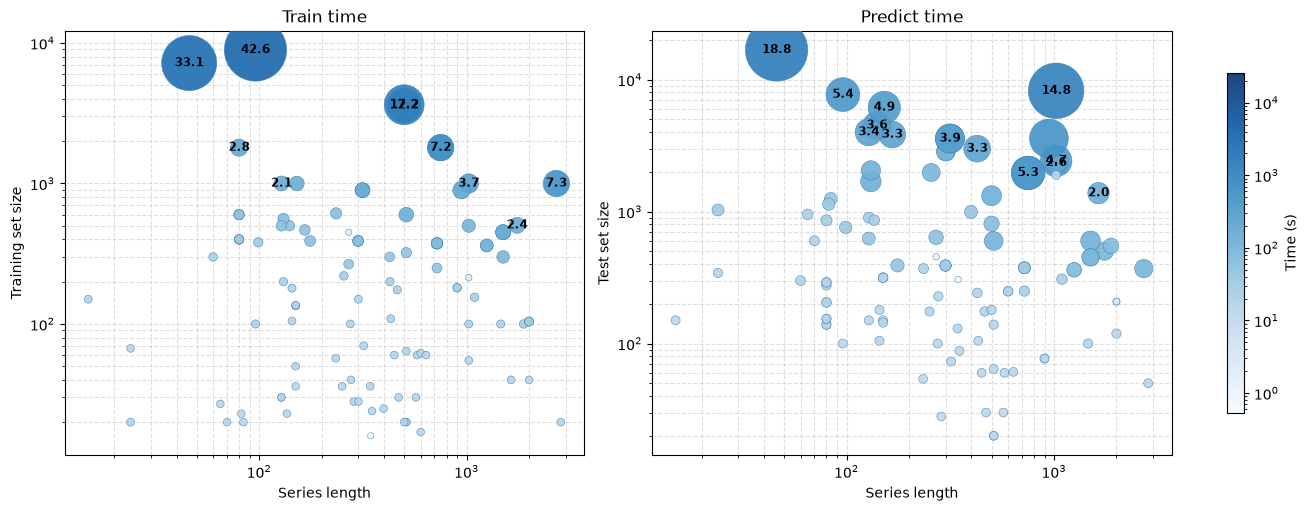

In [8]:
# TSCGlue-H train and predict time (16 CPUs + 1 GPU) over the dataset space, redrawn from
# paper-figures.ipynb with the timing sweep in timing_results_tsp (resample 0). Bubble size and
# colour are the time; labels give minutes for runs over 2 minutes.
import numpy as np

TIMING_RUN = Path("..") / "timing_results_tsp" / "tscglue-high_16cpu_gpu" / "TSCGlueEnhancedV4-High-LogLoss-GPU"
UNIT_TO_S = {"MILLISECONDS": 1e-3, "SECONDS": 1.0, "NANOSECONDS": 1e-9, "MINUTES": 60.0}
# Left unlabelled in the original figure, where their labels overlap a neighbour's.
UNLABELLED = {
    "Adiac", "Beef", "CricketY", "CricketZ", "DistalPhalanxOutlineAgeGroup",
    "DistalPhalanxOutlineCorrect", "DodgerLoopGame", "DodgerLoopWeekend", "ECG200", "FaceAll",
    "FacesUCR", "FiftyWords", "GestureMidAirD2", "GestureMidAirD3", "GesturePebbleZ2",
    "GunPointAgeSpan", "GunPointMaleVersusFemale", "GunPointOldVersusYoung", "Herring",
    "InsectEPGSmallTrain", "InsectWingbeatSound", "Lightning7", "MiddlePhalanxOutlineCorrect",
    "MiddlePhalanxTW", "MixedShapesSmallTrain", "NonInvasiveFetalECGThorax2", "OSULeaf",
    "ProximalPhalanxOutlineCorrect", "ProximalPhalanxTW", "SemgHandGenderCh2",
    "SemgHandMovementCh2", "SemgHandSubjectCh2", "SonyAIBORobotSurface2", "Strawberry",
    "SwedishLeaf", "ToeSegmentation2", "UWaveGestureLibraryAll", "UWaveGestureLibraryX",
    "UWaveGestureLibraryY", "WordSynonyms", "Worms",
}

rows = []
for f in sorted(TIMING_RUN.glob("Predictions/*/testResample0.csv")):
    with open(f) as fh:
        unit = fh.readline().split(",")[4]
        params = fh.readline()
        result = fh.readline().split(",")
    assert "'n_jobs': 16" in params and "'n_gpus': 1" in params, f
    ds = f.parent.name
    X_train, _ = load_classification(ds, split="train", extract_path="../data")
    X_test, _ = load_classification(ds, split="test", extract_path="../data")
    rows.append({
        "dataset": ds,
        "series_len": X_train.shape[-1],
        "n_train": len(X_train),
        "n_test": len(X_test),
        "train_time_s": float(result[1]) * UNIT_TO_S[unit],
        "predict_time_s": float(result[2]) * UNIT_TO_S[unit],
    })
timing = pd.DataFrame(rows)
print(f"{len(timing)} datasets")

t_all = np.concatenate([timing["train_time_s"], timing["predict_time_s"]])
shared_norm = plt.matplotlib.colors.LogNorm(vmin=t_all.min(), vmax=t_all.max() * 10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, time_col, title, n_col, ylabel in [
    (axes[0], "train_time_s", "Train time", "n_train", "Training set size"),
    (axes[1], "predict_time_s", "Predict time", "n_test", "Test set size"),
]:
    t = timing[time_col].to_numpy()
    sc = ax.scatter(
        timing["series_len"], timing[n_col], s=(t / t.max()) * 2000 + 20, c=t,
        cmap="Blues", norm=shared_norm, alpha=0.9, edgecolors="steelblue", linewidths=0.4, zorder=3,
    )
    for xi, yi, ds, ti in zip(timing["series_len"], timing[n_col], timing["dataset"], t):
        if ti > 120 and ds not in UNLABELLED:
            ax.annotate(f"{ti / 60:.1f}", (xi, yi), ha="center", va="center",
                        fontsize=8.5, fontweight="bold", color="black", zorder=4)
    ax.set_xlabel("Series length")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

fig.colorbar(sc, ax=axes, label="Time (s)", shrink=0.8)
fig.savefig(FIGURES / "train_inference_time_16cpu_gpu.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

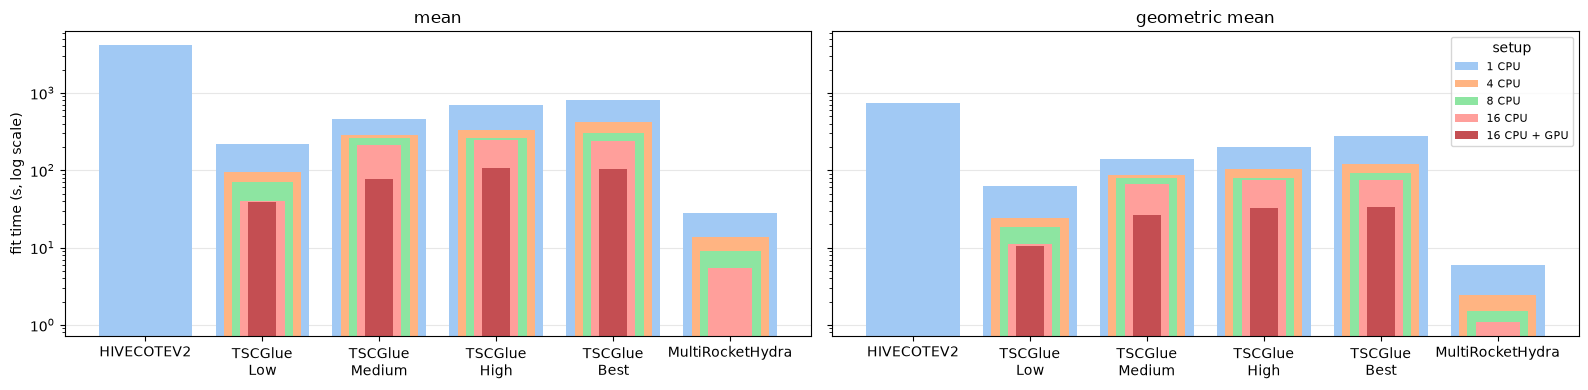

In [9]:
# Fit time per model and hardware setup, arithmetic mean (left) vs geometric mean (right),
# from the timing sweep in timing_results_tsp (as in 083-timing-distributions.ipynb). Setups
# are nested bars, 1 CPU widest at the back; means cover all finished datasets per run.
import ast

import polars as pl
import seaborn as sns

TIMING_RESULTS = Path("..") / "timing_results_tsp"
UNIT_TO_S = {"MILLISECONDS": 1e-3, "SECONDS": 1.0, "NANOSECONDS": 1e-9, "MINUTES": 60.0}

rows = []
for f in sorted(TIMING_RESULTS.glob("*/*/Predictions/*/testResample*.csv")):
    with open(f) as fh:
        header = fh.readline().rstrip("\n").split(",")
        params_line = fh.readline().rstrip("\n")
        result = fh.readline().rstrip("\n").split(",")
    try:
        params = ast.literal_eval(params_line)
    except (ValueError, SyntaxError):
        params = {}
    rows.append(
        {
            "model": f.parents[2].name,
            "n_gpus": params.get("n_gpus"),
            "n_jobs": params.get("n_jobs"),
            "fit_s": float(result[1]) * UNIT_TO_S[header[4]],
        }
    )
df = pl.DataFrame(rows, infer_schema_length=None)

jobs = sorted(df.filter((pl.col("n_gpus") == 0) | pl.col("n_gpus").is_null())["n_jobs"].unique().to_list())
setup = (pl.col("n_jobs").cast(pl.String) + " CPU") + pl.when(pl.col("n_gpus") == 1).then(pl.lit(" + GPU")).otherwise(pl.lit(""))
setups = [f"{j} CPU" for j in jobs] + ["16 CPU + GPU"]
groups = ["HIVECOTEV2"] + [f"TSCGlueEnhancedV4-{p}-LogLoss-GPU" for p in ["Low", "Medium", "High", "Best"]] + ["MultiRocketHydra"]
labels = ["HIVECOTEV2", "TSCGlue\nLow", "TSCGlue\nMedium", "TSCGlue\nHigh", "TSCGlue\nBest", "MultiRocketHydra"]
setup_colors = dict(zip(setups, sns.color_palette("pastel", len(setups))))
setup_colors["16 CPU + GPU"] = sns.color_palette("deep")[3]  # darker shade of the 16 CPU red

aggs = {
    "mean": pl.col("fit_s").mean(),
    "geometric mean": pl.col("fit_s").log().mean().exp(),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
for ax, (name, expr) in zip(axes, aggs.items()):
    val = {(m, s): v for m, s, v in df.group_by("model", setup.alias("setup")).agg(expr).iter_rows()}
    for k, m in enumerate(groups):
        for i, s in enumerate(setups):
            v = val.get((m, s))
            if v is not None:
                ax.bar(k, v, width=0.8 - 0.14 * i, color=setup_colors[s], label=s if k == 1 else None)
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(labels)
    ax.set_yscale("log")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_title(name)
axes[0].set_ylabel("fit time (s, log scale)")
axes[1].legend(title="setup", fontsize=8, loc="upper right")
plt.tight_layout()
fig.savefig(FIGURES / "fit_time_mean_vs_geomean.pdf", bbox_inches="tight", pad_inches=0)
plt.show()